In [41]:
import Pkg
Pkg.activate(".");

  Activating project at `~/Documents/MPSTime.jl`


In [42]:
using Plots
using MPSTime
using Random
using StatsBase
using StatsPlots
using Distributions
using Plots.PlotMeasures
using ProgressMeter
default(;fontfamily = "Computer Modern", xtickfont=12, ytickfont=12, guidefont=12, 
    bottom_margin=8mm, left_margin=8mm, right_margin=8mm, titlefont=12, c=palette(:tab10))

In [68]:
T = 100 # time series length
n_train = 500 # number of time series instances
period = 30.0 # fix the period
slope = 1.0 # fix the slope
intervals = 4 # set the number of intervals
phase_train = collect(LinRange(0, 2pi-0.001, intervals))
sigma = 0.05
train, train_info = trendy_sine(T, n_train; period=period, slope=slope, phase=phase_train, sigma=sigma, rng=Xoshiro(12345));

In [67]:
countmap(train_info[:phase])

Dict{Float64, Int64} with 4 entries:
  0.0     => 261
  2.09406 => 233
  4.18812 => 242
  6.28219 => 264

In [49]:
n_test = 500
phase_test = collect(LinRange(0, 2pi, n_test))
test = Matrix{Float64}(undef, n_test, T)
test_phases = Vector{Float64}(undef, n_test)
for i in 1:n_test
    inst, inf = trendy_sine(T, 1; period=period, slope=slope, phase=phase_test[i], sigma=sigma);
    test_phases[i] = inf[:phase][1]
    test[i, :] = inst
end

In [61]:
opts = MPSOptions(d=8, chi_max=60, nsweeps=10, eta=0.1, sigmoid_transform=false);

In [62]:
mps, _, _ = fitMPS(train, opts);

Generating initial weight MPS with bond dimension χ_init = 4
        using random state 1234.
Initialising train states.
blas_name = "LBTConfig([ILP64] libopenblas64_.dylib)"
Using 1 iterations per update.
Training KL Div. 126.20257924752129 | Training acc. 1.0.

┌ Warning: Not using MKL BLAS, which may lead to worse performance.
│ To fix this, Import MPSTime into Julia first or use the MKL package
└ @ MPSTime /Users/jmoo2880/Documents/MPSTime.jl/src/Training/RealRealHighDimension.jl:715



Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [1/10]
Backward sweep finished.
Starting forward sweep: [1/10]
Finished sweep 1. Time for sweep: 15.48s
Training KL Div. -105.33431890901252 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [2/10]
Backward sweep finished.
Starting forward sweep: [2/10]
Finished sweep 2. Time for sweep: 64.04s
Training KL Div. -105.45790122303707 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [3/10]
Backward sweep finished.
Starting forward sweep: [3/10]
Finished sweep 3. Time for sweep: 65.38s
Training KL Div. -105.47439233787115 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [4/10]
Backward sweep finished.
Starting forward sweep: [4/10]
Finished sweep 4. Time for sweep: 66.51s
Training KL Div. -105.4812012487196 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" alg

In [63]:
imp = init_imputation_problem(mps, test)

Initialising train states.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
                         Summary:

 - Dataset has 500 training samples and 500 testing samples.
Slicing MPS into individual states...
 - 1 class(es) were detected.
 - Time independent encoding - Legendre - detected.
 - d = 8, chi_max = 60
Re-encoding the training data to get the encoding arguments...

 Created 1 ImputationProblem struct(s) containing class-wise mps and test samples.


ImputationProblem(ITensors.ITensorMPS.MPS[ITensors.ITensorMPS.MPS
[1] ((dim=8|id=893|"Site,n=1"), (dim=8|id=991|"Link,l=1"))
[2] ((dim=8|id=572|"Site,n=2"), (dim=8|id=991|"Link,l=1"), (dim=32|id=982|"Link,l=2"))
[3] ((dim=8|id=657|"Site,n=3"), (dim=32|id=982|"Link,l=2"), (dim=60|id=805|"Link,l=3"))
[4] ((dim=8|id=110|"Site,n=4"), (dim=60|id=805|"Link,l=3"), (dim=60|id=790|"Link,l=4"))
[5] ((dim=8|id=360|"Site,n=5"), (dim=60|id=790|"Link,l=4"), (dim=60|id=473|"Link,l=5"))
[6] ((dim=8|id=819|"Site,n=6"), (dim=60|id=473|"Link,l=5"), (dim=60|id=541|"Link,l=6"))
[7] ((dim=8|id=27|"Site,n=7"), (dim=60|id=541|"Link,l=6"), (dim=60|id=800|"Link,l=7"))
[8] ((dim=8|id=372|"Site,n=8"), (dim=60|id=800|"Link,l=7"), (dim=60|id=986|"Link,l=8"))
[9] ((dim=8|id=173|"Site,n=9"), (dim=60|id=986|"Link,l=8"), (dim=60|id=340|"Link,l=9"))
[10] ((dim=8|id=878|"Site,n=10"), (dim=60|id=340|"Link,l=9"), (dim=60|id=192|"Link,l=10"))
[11] ((dim=8|id=50|"Site,n=11"), (dim=60|id=192|"Link,l=10"), (dim=60|id=358|"Link

In [64]:
class = 0
method = :median
pm = 0.5
score_mps = Vector{Float64}(undef, size(test, 1))
score_nn = Vector{Float64}(undef, size(test, 1))
imp = init_imputation_problem(mps, test)
@showprogress Threads.@threads for instance in 1:size(test, 1)
    window_loc_score_mps = []
    window_loc_score_nn = []
    for i in 1:5
        _, impute_sites = mar(test[instance, :], pm) 
        imputed_ts, pred_err, target_ts, stats, plots = MPS_impute(imp, class, instance, impute_sites, method; NN_baseline=true, plot_fits=false);
        push!(window_loc_score_mps, stats[1][:MAE])
        push!(window_loc_score_nn, stats[1][:NN_MAE])
    end
    score_mps[instance] = mean(window_loc_score_mps)
    score_nn[instance] = mean(window_loc_score_nn)
end

Initialising train states.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
                         Summary:

 - Dataset has 500 training samples and 500 testing samples.
Slicing MPS into individual states...
 - 1 class(es) were detected.
 - Time independent encoding - Legendre - detected.
 - d = 8, chi_max = 60
Re-encoding the training data to get the encoding arguments...

 Created 1 ImputationProblem struct(s) containing class-wise mps and test samples.


Progress:   5%|██                                       |  ETA: 1:03:10

The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training se

Progress:   5%|██                                       |  ETA: 1:03:05

The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!


Progress: 100%|█████████████████████████████████████████| Time: 1:06:57


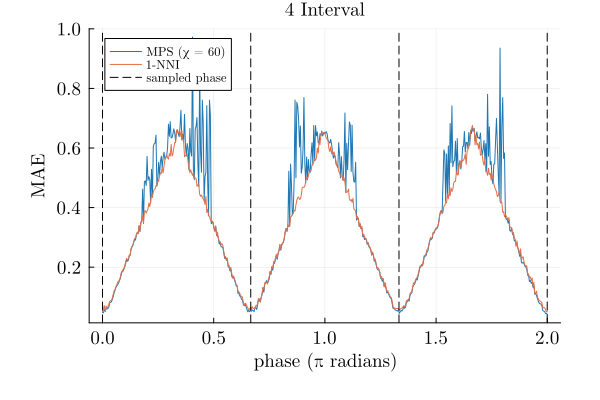

In [65]:
p1 = plot(phase_test./pi, score_mps, label="MPS (χ = $(opts.chi_max))", xlabel="phase (π radians)", ylabel="MAE", title="4 Interval")
plot!(phase_test./pi, score_nn, xlabel="phase (π radians)", ylabel="MAE", c=2, label="1-NNI")
vline!(phase_train/pi, c=:black, ls=:dash, label="sampled phase")
#savefig("4interval_test.svg")

stats = Any[Dict(:MAE => 0.6070575752452324, :MAPE => 2.3242765656825366, :NN_MAE => 0.6023292355192673, :NN_MAPE => 2.3212598656327645)]


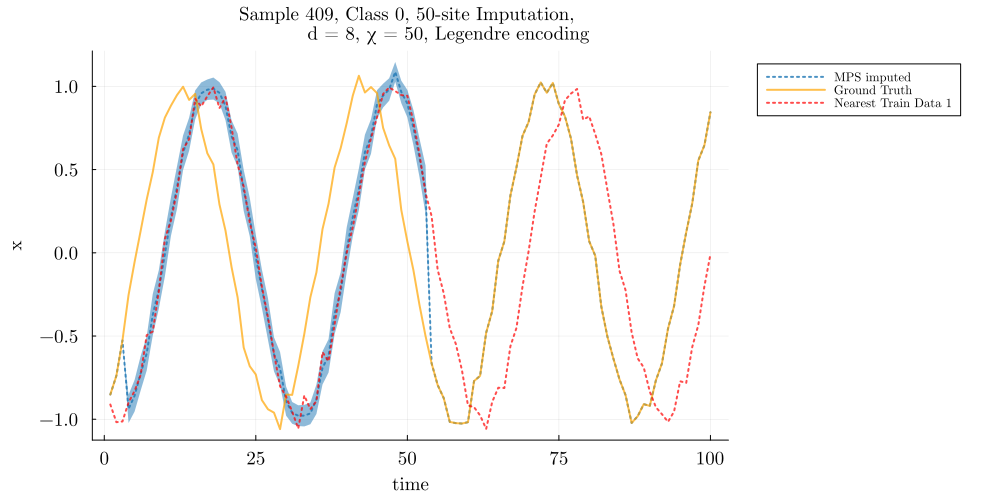

In [140]:
instance = 409
pm = 0.5
_, impute_sites = mar(test[instance, :], pm) 
imputed_ts, pred_err, target_ts, stats, plots = MPS_impute(imp, class, instance, impute_sites, method; NN_baseline=true, plot_fits=true);
score_mps[instance] = stats[1][:MAE]
@show stats
plot(plots...)

In [81]:
T = 100 # time series length
n_train = 500 # number of time series instances
period = 30.0 # fix the period
slope = 1.0 # fix the slope
intervals = 8 # set the number of intervals
phase_train = collect(LinRange(0, 2pi-0.001, intervals))
sigma = 0.05
train, train_info = trendy_sine(T, n_train; period=period, slope=slope, phase=phase_train, sigma=sigma, rng=Xoshiro(9876));

In [82]:
opts = MPSOptions(d=8, chi_max=60, nsweeps=10, eta=0.01, sigmoid_transform=false);

In [83]:
mps, _, _ = fitMPS(train, opts);

In [84]:
imp = init_imputation_problem(mps, test)

ImputationProblem(ITensors.ITensorMPS.MPS[ITensors.ITensorMPS.MPS
[1] ((dim=8|id=762|"Site,n=1"), (dim=8|id=159|"Link,l=1"))
[2] ((dim=8|id=220|"Site,n=2"), (dim=8|id=159|"Link,l=1"), (dim=36|id=806|"Link,l=2"))
[3] ((dim=8|id=706|"Site,n=3"), (dim=36|id=806|"Link,l=2"), (dim=60|id=680|"Link,l=3"))
[4] ((dim=8|id=255|"Site,n=4"), (dim=60|id=680|"Link,l=3"), (dim=60|id=879|"Link,l=4"))
[5] ((dim=8|id=657|"Site,n=5"), (dim=60|id=879|"Link,l=4"), (dim=60|id=190|"Link,l=5"))
[6] ((dim=8|id=961|"Site,n=6"), (dim=60|id=190|"Link,l=5"), (dim=60|id=257|"Link,l=6"))
[7] ((dim=8|id=710|"Site,n=7"), (dim=60|id=257|"Link,l=6"), (dim=60|id=609|"Link,l=7"))
[8] ((dim=8|id=891|"Site,n=8"), (dim=60|id=609|"Link,l=7"), (dim=60|id=894|"Link,l=8"))
[9] ((dim=8|id=594|"Site,n=9"), (dim=60|id=894|"Link,l=8"), (dim=60|id=995|"Link,l=9"))
[10] ((dim=8|id=700|"Site,n=10"), (dim=60|id=995|"Link,l=9"), (dim=60|id=162|"Link,l=10"))
[11] ((dim=8|id=196|"Site,n=11"), (dim=60|id=162|"Link,l=10"), (dim=60|id=487|"Li

In [85]:
class = 0
method = :median
pm = 0.5
score_mps = Vector{Float64}(undef, size(test, 1))
score_nn = Vector{Float64}(undef, size(test, 1))
imp = init_imputation_problem(mps, test)
@showprogress Threads.@threads for instance in 1:size(test, 1)
    window_loc_score_mps = []
    window_loc_score_nn = []
    for i in 1:5
        _, impute_sites = mar(test[instance, :], pm) 
        imputed_ts, pred_err, target_ts, stats, plots = MPS_impute(imp, class, instance, impute_sites, method; NN_baseline=true, plot_fits=false);
        push!(window_loc_score_mps, stats[1][:MAE])
        push!(window_loc_score_nn, stats[1][:NN_MAE])
    end
    score_mps[instance] = mean(window_loc_score_mps)
    score_nn[instance] = mean(window_loc_score_nn)
end

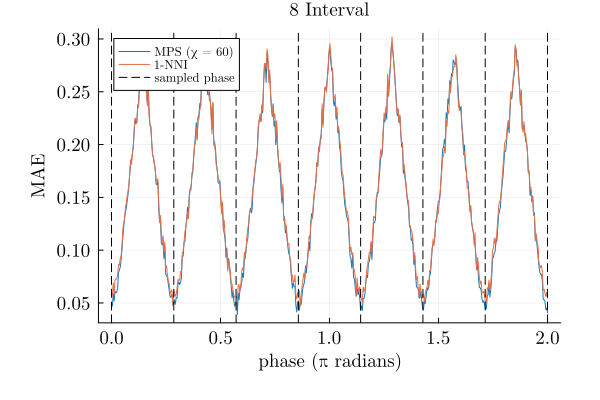

In [87]:
p1 = plot(phase_test./pi, score_mps, label="MPS (χ = $(opts.chi_max))", xlabel="phase (π radians)", ylabel="MAE", title="$intervals Interval")
plot!(phase_test./pi, score_nn, xlabel="phase (π radians)", ylabel="MAE", c=2, label="1-NNI")
vline!(phase_train/pi, c=:black, ls=:dash, label="sampled phase")
#savefig("8interval_test.svg")

In [88]:
T = 100 # time series length
n_train = 1000 # number of time series instances
period = 30.0 # fix the period
slope = 0.0 # fix the slope
intervals = 32 # set the number of intervals
phase_train = collect(LinRange(0, 2pi-0.001, intervals))
sigma = 0.05
train, train_info = trendy_sine(T, n_train; period=period, slope=slope, phase=phase_train, sigma=sigma, rng=Xoshiro(8465));

In [89]:
countmap(train_info[:phase])

Dict{Float64, Int64} with 32 entries:
  3.03977  => 25
  1.62121  => 24
  2.63446  => 30
  3.85037  => 34
  2.43181  => 32
  5.67423  => 29
  0.202651 => 34
  2.02651  => 46
  6.28219  => 31
  0.607953 => 31
  0.0      => 29
  0.405302 => 31
  0.810605 => 30
  4.86363  => 30
  5.87688  => 32
  1.21591  => 27
  5.26893  => 35
  1.01326  => 28
  4.05302  => 43
  ⋮        => ⋮

In [90]:
opts = MPSOptions(d=8, chi_max=60, nsweeps=10, eta=0.1, sigmoid_transform=false);
mps, _, _ = fitMPS(train, opts);

In [92]:
n_test = 500
phase_test = collect(LinRange(0, 2pi, n_test))
test = Matrix{Float64}(undef, n_test, T)
test_phases = Vector{Float64}(undef, n_test)
for i in 1:n_test
    inst, inf = trendy_sine(T, 1; period=period, slope=slope, phase=phase_test[i], sigma=sigma);
    test_phases[i] = inf[:phase][1]
    test[i, :] = inst
end

In [93]:
class = 0
method = :median
pm = 0.5
score_mps = Vector{Float64}(undef, size(test, 1))
score_nn = Vector{Float64}(undef, size(test, 1))
imp = init_imputation_problem(mps, test)
@showprogress Threads.@threads for instance in 1:size(test, 1)
    window_loc_score_mps = []
    window_loc_score_nn = []
    for i in 1:5
        _, impute_sites = mar(test[instance, :], pm) 
        imputed_ts, pred_err, target_ts, stats, plots = MPS_impute(imp, class, instance, impute_sites, method; NN_baseline=true, plot_fits=false);
        push!(window_loc_score_mps, stats[1][:MAE])
        push!(window_loc_score_nn, stats[1][:NN_MAE])
    end
    score_mps[instance] = mean(window_loc_score_mps)
    score_nn[instance] = mean(window_loc_score_nn)
end

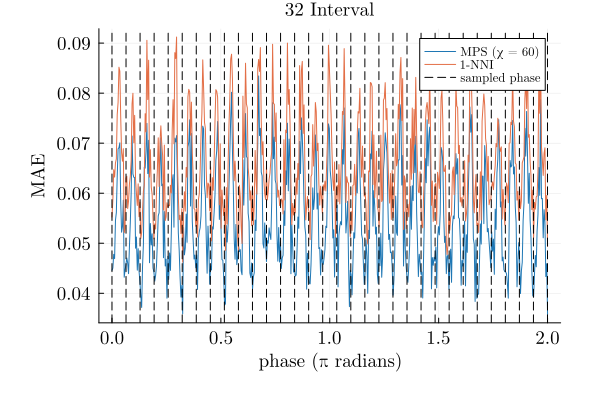

In [94]:
p1 = plot(phase_test./pi, score_mps, label="MPS (χ = $(opts.chi_max))", xlabel="phase (π radians)", ylabel="MAE", title="$intervals Interval")
plot!(phase_test./pi, score_nn, xlabel="phase (π radians)", ylabel="MAE", c=2, label="1-NNI")
vline!(phase_train/pi, c=:black, ls=:dash, label="sampled phase")
#savefig("32interval_test.svg")

In [30]:
T = 100 # time series length
n_train = 500 # number of time series instances
period = 30.0 # fix the period
slope = 0.0 # fix the slope
phase_train = collect(LinRange(0, 2pi, n_train))
sigma = 0.05
train, train_info = trendy_sine(T, n_train; period=period, slope=slope, phase=phase_train, sigma=sigma, rng=Xoshiro(145));

In [32]:
opts = MPSOptions(d=8, chi_max=50, nsweeps=10, eta=0.01, sigmoid_transform=false);
mps, _, _ = fitMPS(train, opts);

Generating initial weight MPS with bond dimension χ_init = 4
        using random state 1234.
Initialising train states.


┌ Warning: Not using MKL BLAS, which may lead to worse performance.
│ To fix this, Import MPSTime into Julia first or use the MKL package
└ @ MPSTime /Users/jmoo2880/Documents/MPSTime.jl/src/Training/RealRealHighDimension.jl:715


blas_name = "LBTConfig([ILP64] libopenblas64_.dylib)"
Using 1 iterations per update.
Training KL Div. 112.89848044163969 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [1/10]
Backward sweep finished.
Starting forward sweep: [1/10]
Finished sweep 1. Time for sweep: 18.98s
Training KL Div. -92.13468476255629 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [2/10]
Backward sweep finished.
Starting forward sweep: [2/10]
Finished sweep 2. Time for sweep: 51.83s
Training KL Div. -98.33399288111461 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [3/10]
Backward sweep finished.
Starting forward sweep: [3/10]
Finished sweep 3. Time for sweep: 52.05s
Training KL Div. -100.1108464206225 | Training acc. 1.0.
Using optimiser CustomGD with the "TSGO" algorithm
Starting backward sweeep: [4/10]
Backward sweep finished.
Starting forward sweep: [4/10]
Fini

In [33]:
n_test = 500
phase_test = collect(LinRange(0, 2pi, n_test))
test = Matrix{Float64}(undef, n_test, T)
test_phases = Vector{Float64}(undef, n_test)
for i in 1:n_test
    inst, inf = trendy_sine(T, 1; period=period, slope=slope, phase=phase_test[i], sigma=sigma);
    test_phases[i] = inf[:phase][1]
    test[i, :] = inst
end

In [34]:
class = 0
method = :median
pm = 0.5
score_mps = Vector{Float64}(undef, size(test, 1))
score_nn = Vector{Float64}(undef, size(test, 1))
imp = init_imputation_problem(mps, test)
@showprogress Threads.@threads for instance in 1:size(test, 1)
    window_loc_score_mps = []
    window_loc_score_nn = []
    for i in 1:3
        _, impute_sites = mar(test[instance, :], pm) 
        imputed_ts, pred_err, target_ts, stats, plots = MPS_impute(imp, class, instance, impute_sites, method; NN_baseline=true, plot_fits=false);
        push!(window_loc_score_mps, stats[1][:MAE])
        push!(window_loc_score_nn, stats[1][:NN_MAE])
    end
    score_mps[instance] = mean(window_loc_score_mps)
    score_nn[instance] = mean(window_loc_score_nn)
end

Initialising train states.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
                         Summary:

 - Dataset has 500 training samples and 500 testing samples.
Slicing MPS into individual states...
 - 1 class(es) were detected.
 - Time independent encoding - Legendre - detected.
 - d = 8, chi_max = 50
Re-encoding the training data to get the encoding arguments...

 Created 1 ImputationProblem struct(s) containing class-wise mps and test samples.


Progress:  51%|████████████████████▉                    |  ETA: 0:18:43

The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training se

Progress:  51%|█████████████████████                    |  ETA: 0:18:39

The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!


Progress:  82%|█████████████████████████████████▋       |  ETA: 0:06:56

The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training set normalization, 1 additional rescaling operations had to be performed!
The test set couldn't be perfectly rescaled by the training se

Progress: 100%|█████████████████████████████████████████| Time: 0:38:31


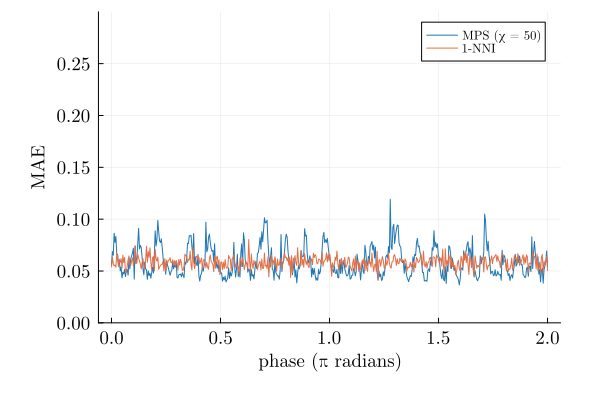

In [39]:
p1 = plot(phase_test./pi, score_mps, label="MPS (χ = $(opts.chi_max))", xlabel="phase (π radians)", ylabel="MAE", ylims=(0, 0.3))
plot!(phase_test./pi, score_nn, xlabel="phase (π radians)", ylabel="MAE", c=2, label="1-NNI")

-----